In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
import seaborn as sns

### **Dataset containing in this document:**


*   ***discoveries:*** the number of "great" inventions and scientific discoveries from 1860 to 1959.
*   ***co2_levels:*** time series data on global CO2 levels measured at the Mauna Loa Observatory, Hawaii.
*   ***airline_passengers:*** monthly number of passengers who took a commercial flight between January 1949 and December 1960.
*   ***employment:*** the unemployment rate of different industries in the USA during the years of 2000-2010. The dataset contains time series for 16 industries and across 122 timepoints (one per month for 10 years).






# **A Basic Time Series Line Plot**

In [ ]:
discoveries = pd.read_csv('/content/drive/MyDrive/Python Resources/url_discoveries.csv')
print(discoveries.head(n=5))

         date  Y
0  01-01-1860  5
1  01-01-1861  3
2  01-01-1862  0
3  01-01-1863  2
4  01-01-1864  0


In [ ]:
# Convert the date column to a datestamp type
discoveries['date'] = pd.to_datetime(discoveries['date'])
discoveries = discoveries.set_index('date')

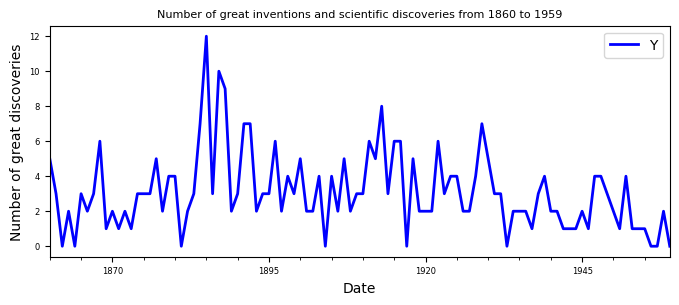

In [ ]:
ax = discoveries.plot(color='blue', figsize=(8, 3), linewidth=2, fontsize=6)
ax.set_title('Number of great inventions and scientific discoveries from 1860 to 1959', fontsize=8)
ax.set_xlabel('Date')
ax.set_ylabel('Number of great discoveries')
plt.show()

# **Summary Statistics and Diagnostics**

In [ ]:
co2_levels = pd.read_csv('/content/drive/MyDrive/Python Resources/co2_levels.csv')
print(co2_levels.head(n=5))

    datestamp    co2
0  1958-03-29  316.1
1  1958-04-05  317.3
2  1958-04-12  317.6
3  1958-04-19  317.5
4  1958-04-26  316.4


In [ ]:
# Set datestamp column as index
co2_levels = co2_levels.set_index('datestamp')

# Print out the number of missing values
print(co2_levels.isnull().sum())

co2    59
dtype: int64


In [ ]:
# Impute missing values with the next valid observation
co2_levels = co2_levels.bfill()
# Print out the number of missing values
print(co2_levels.isnull().sum())

co2    0
dtype: int64


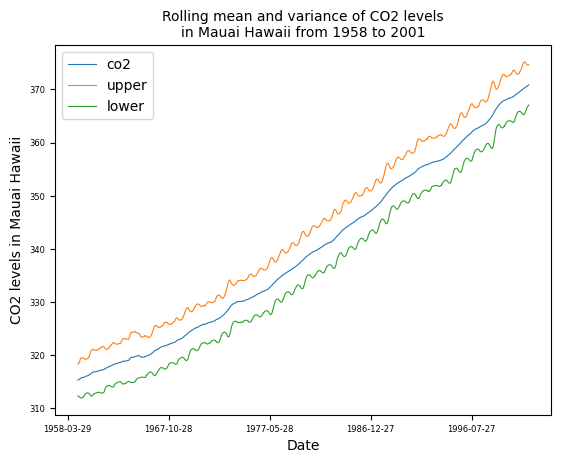

In [ ]:
# Compute the 52 weeks rolling mean and standard deviation of the co2_levels DataFrame
ma = co2_levels.rolling(window=52).mean()
mstd = co2_levels.rolling(window=52).std()

# Add the upper/lower bound column to the ma DataFrame
ma['upper'] = ma['co2'] + (2 * mstd['co2'])
ma['lower'] = ma['co2'] - (2 * mstd['co2'])

# Plot the content of the ma DataFrame
ax = ma.plot(linewidth=0.8, fontsize=6)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('CO2 levels in Mauai Hawaii', fontsize=10)
ax.set_title('Rolling mean and variance of CO2 levels\nin Mauai Hawaii from 1958 to 2001', fontsize=10)
plt.show()

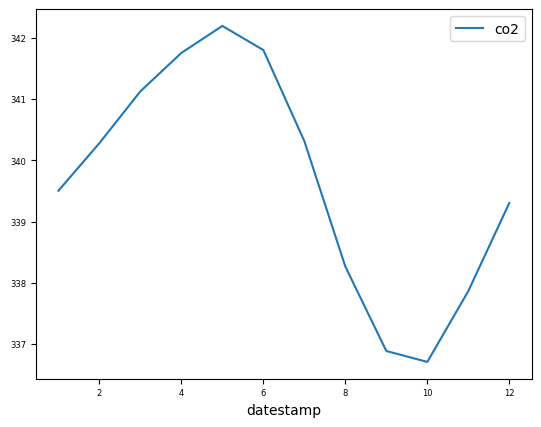

In [ ]:
# Get month for each dates in the index of co2_levels
co2_levels.index = pd.to_datetime(co2_levels.index)
index_month = co2_levels.index.month

# Compute the mean CO2 levels for each month of the year
mean_co2_levels_by_month = co2_levels.groupby(index_month).mean()

# Plot the mean CO2 levels for each month of the year
mean_co2_levels_by_month.plot(fontsize=6)
plt.legend(fontsize=10)
plt.show()

In [ ]:
print(co2_levels.describe())

               co2
count  2284.000000
mean    339.657750
std      17.100899
min     313.000000
25%     323.975000
50%     337.700000
75%     354.500000
max     373.900000


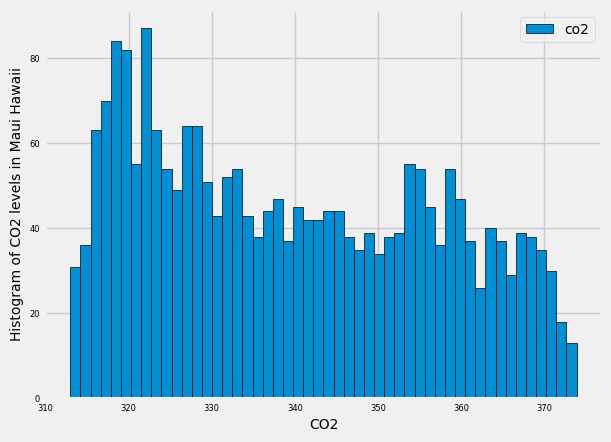

In [ ]:
# Generate a histogram
plt.style.use('fivethirtyeight')
ax = co2_levels.plot(kind='hist', bins=50, fontsize=6,edgecolor='black',)

# Set the labels and display the plot
ax.set_xlabel('CO2', fontsize=10)
ax.set_ylabel('Histogram of CO2 levels in Maui Hawaii', fontsize=10)
plt.legend(fontsize=10)
plt.show()

## **Seasonality, Trend and Noise**

In [ ]:
airline_passengers = pd.read_csv('/content/drive/MyDrive/Python Resources/airline_passengers.csv')
print(airline_passengers.head(n=5))

     Month  AirPassengers
0  1949-01            112
1  1949-02            118
2  1949-03            132
3  1949-04            129
4  1949-05            121


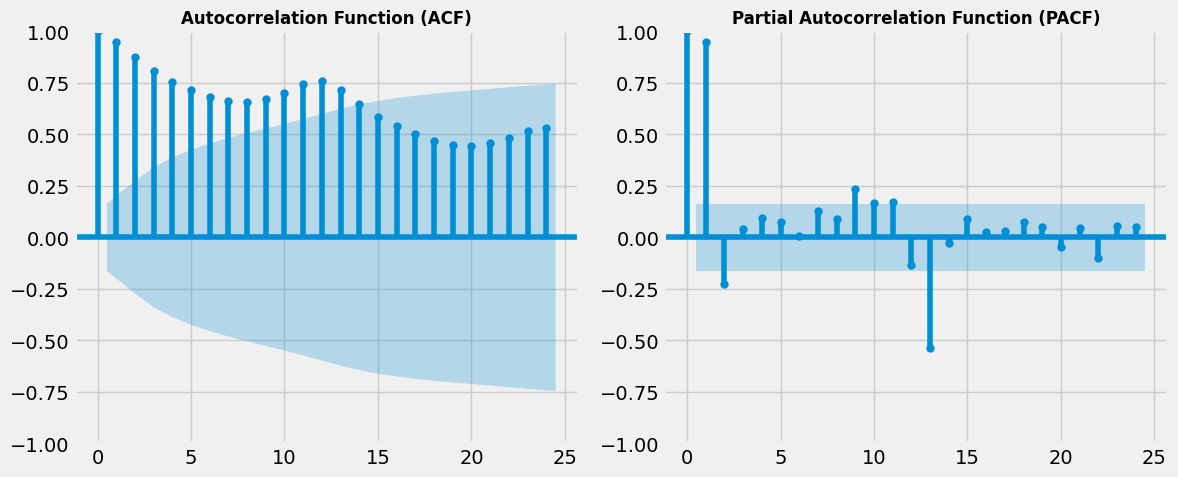

In [ ]:
# Autocorrelation plot and partial autocorrelation plot
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tsaplots.plot_acf(airline_passengers['AirPassengers'], lags=24, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

tsaplots.plot_pacf(airline_passengers['AirPassengers'], lags=24, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

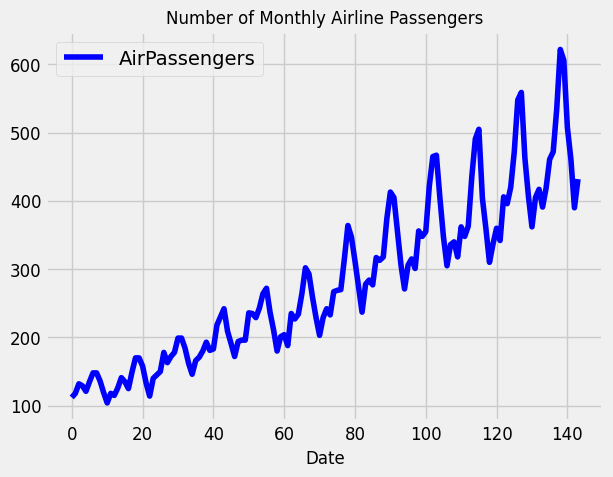

In [ ]:
# Plot the airline_passengers time series
ax = airline_passengers.plot(color = 'blue', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Number of Monthly Airline Passengers', fontsize=12)
plt.show()

In [ ]:
airline_passengers['Month'] = pd.to_datetime(airline_passengers['Month'])
airline_passengers.set_index('Month', inplace=True)

ts = airline_passengers['AirPassengers']

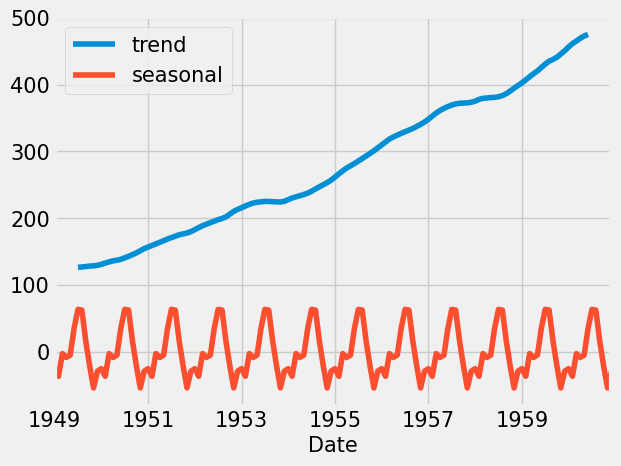

In [ ]:
# Plot the values of the trend and seasonal component and airline_decomposed DataFrame
# Perform time series decompositon
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=12)

airline_decomposed = pd.DataFrame({
    'trend': decomposition.trend,
    'seasonal': decomposition.seasonal
})

ax = airline_decomposed.plot(fontsize=15)
ax.set_xlabel('Date', fontsize=15)
plt.legend(fontsize=15)
plt.show()

## **Work with Multiple Time Series**

In [ ]:
# Read in employment file
employment = pd.read_csv('/content/drive/MyDrive/Python Resources/employment.csv')

# Convert datestamp column to a datetime object and set it as the index
employment['datestamp'] = pd.to_datetime(employment['datestamp'])
employment = employment.set_index('datestamp')

# Check the number of missing values in each column
print(employment.isnull().sum())

Agriculture                       0
Business services                 0
Construction                      0
Durable goods manufacturing       0
Education and Health              0
Finance                           0
Government                        0
Information                       0
Leisure and hospitality           0
Manufacturing                     0
Mining and Extraction             0
Nondurable goods manufacturing    0
Other                             0
Self-employed                     0
Transportation and Utilities      0
Wholesale and Retail Trade        0
dtype: int64


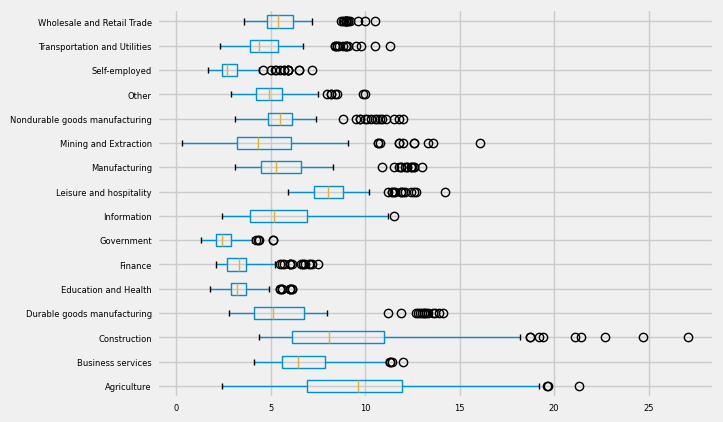

In [ ]:
# Generate a boxplot
employment.boxplot(fontsize=6, vert=False)
plt.show()

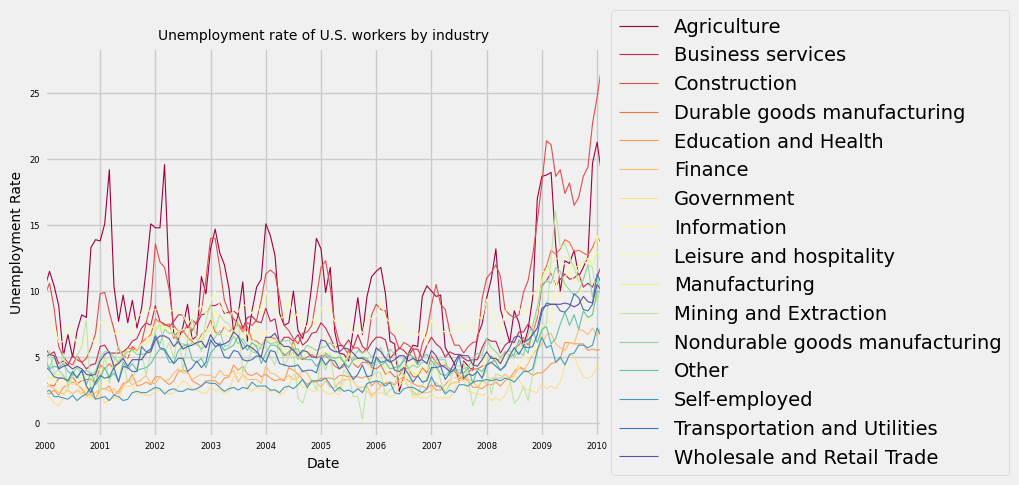

In [ ]:
# Plot all time series in the DataFrame
ax = employment.plot(colormap = 'Spectral', fontsize=6, linewidth=0.8)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Unemployment Rate', fontsize=10)
ax.set_title('Unemployment rate of U.S. workers by industry', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

In [ ]:
# Apply decomposition for all columns in the set
employment_decomp = {}
employment_names = employment.columns

for ts in employment_names:
    ts_decomposition = sm.tsa.seasonal_decompose(employment[ts])
    employment_decomp[ts] = ts_decomposition

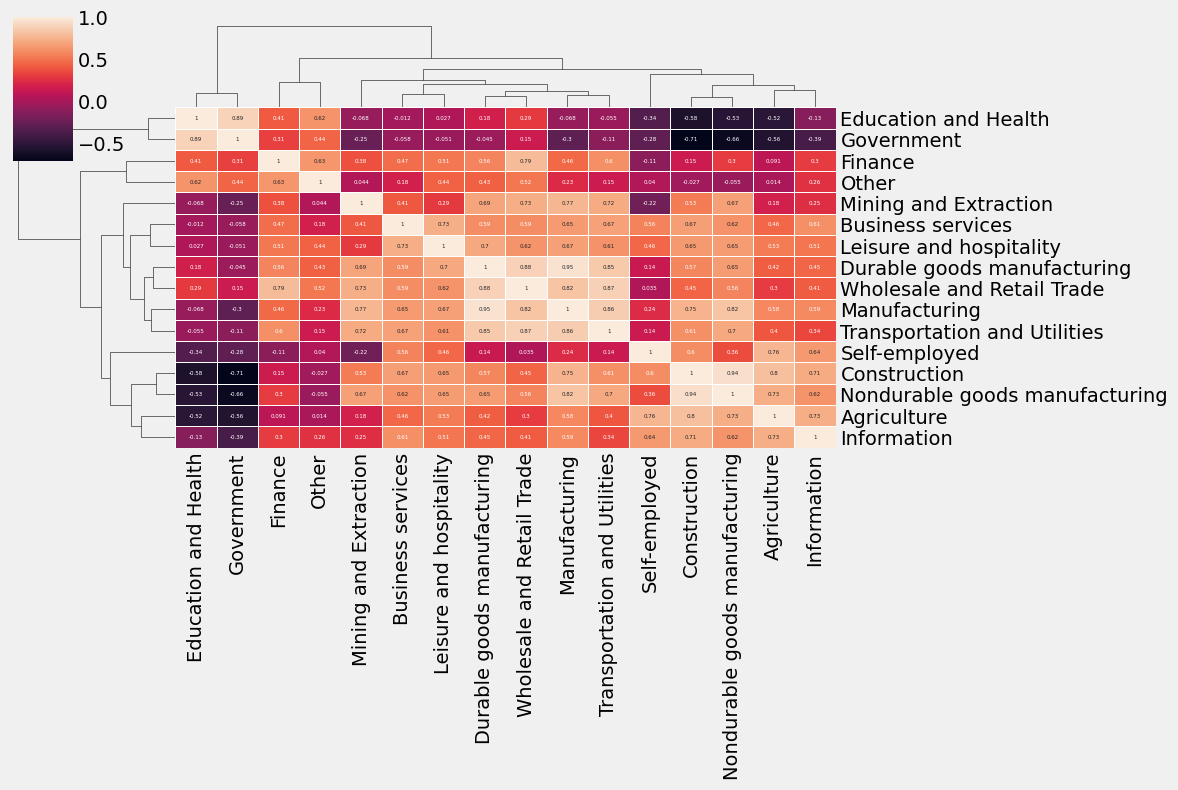

In [ ]:
# Extract the seasonal values for the decomposition of each time series
employment_seasonal = {}

for ts in employment_names:
    employment_seasonal[ts] = employment_decomp[ts].seasonal

# Create a DataFrame from the employment_seasonal dictionary
seasonality_df = pd.DataFrame(employment_seasonal)

# Correlations between multiple time series
seasonality_corr = seasonality_df.corr(method = 'spearman')

fig = sns.clustermap(seasonality_corr, annot=True, annot_kws={"size": 4}, linewidths=.4, figsize=(12, 8))
plt.setp(fig.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
plt.setp(fig.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)
plt.show()